## BACKTESTING CON VENTANA MÓVIL Y REBALANCEO

Fase 9 — La prueba realmente rigurosa del proyecto. A diferencia de las fases anteriores (donde `mu` y la covarianza se estimaron con **todo** el periodo y luego se evaluó sobre ese mismo periodo), aquí cada decisión de inversión usa **únicamente información disponible hasta ese momento**, y el portafolio se rebalancea periódicamente.

### Por qué esta fase cambia todo

En las Fases 5-8 el optimizador "ya sabía" qué activos habían subido más en 2018-2026, porque estimaste `mu` con ese mismo periodo. Eso se llama **optimización in-sample** y siempre se ve bien — pero no es replicable en la realidad, donde un inversionista en enero de 2021 no puede saber qué pasará en 2024.

Aquí se simula el proceso real:
1. En cada fecha de rebalanceo, se estima `mu` y la covarianza **solo con datos pasados** (ventana móvil).
2. Se optimiza el portafolio con esa información.
3. Se mantienen esos pesos hasta el siguiente rebalanceo, midiendo el retorno real obtenido.
4. Se repite, avanzando en el tiempo.

Es muy común que la ventaja de Markowitz observada in-sample se reduzca o desaparezca en este tipo de evaluación — y ese resultado, si ocurre, es uno de los hallazgos más valiosos del proyecto.

Importación de librerías

In [2]:
%pip install PyPortfolioOpt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier

In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "backtesting_rebalanceo"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "adjusted_prices.csv"
RETURNS_FILE = DATA_DIR / "daily_returns.csv"

benchmark = "^GSPC"

ESTIMATION_WINDOW = 504    # ~2 años de datos para estimar mu y covarianza
REBALANCE_FREQ = 63        # rebalanceo trimestral (~63 días hábiles)
MAX_WEIGHT = 0.15
RISK_FREE_RATE = 0.02
TRANSACTION_COST = 0.001   # 10 puntos base por unidad de rotación (ajustable)

print("Ventana de estimación:", ESTIMATION_WINDOW, "días")
print("Frecuencia de rebalanceo:", REBALANCE_FREQ, "días")


Ventana de estimación: 504 días
Frecuencia de rebalanceo: 63 días


## Carga de datos

In [3]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)
returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

prices.index.name = "Date"
returns.index.name = "Date"

returns_clean = returns.dropna(how="all")
prices_clean = prices.loc[returns_clean.index]

asset_prices = prices_clean.drop(columns=[benchmark])
asset_returns = returns_clean.drop(columns=[benchmark])

print("Activos:", asset_prices.shape[1])
print("Periodo:", asset_prices.index.min().date(), "→", asset_prices.index.max().date())


Activos: 20
Periodo: 2018-01-03 → 2026-08-25


## Función de backtest con ventana móvil

En cada fecha de rebalanceo se usa solo la ventana de datos **anterior** a esa fecha para estimar y optimizar. Los pesos resultantes se aplican al periodo **siguiente**, que el optimizador no vio.

In [4]:
def rolling_backtest(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    strategy: str = "max_sharpe",
    estimation_window: int = ESTIMATION_WINDOW,
    rebalance_freq: int = REBALANCE_FREQ,
    max_weight: float = MAX_WEIGHT,
    transaction_cost: float = TRANSACTION_COST
):
    dates = prices.index
    rebalance_points = range(estimation_window, len(dates), rebalance_freq)

    portfolio_returns = []
    weights_history = {}
    turnover_history = []
    previous_weights = pd.Series(0.0, index=prices.columns)

    for start_idx in rebalance_points:

        # Ventana de estimación: SOLO datos anteriores a la fecha de rebalanceo
        train_prices = prices.iloc[start_idx - estimation_window:start_idx]

        # Periodo de tenencia: datos posteriores, que el optimizador no vio
        end_idx = min(start_idx + rebalance_freq, len(dates))
        hold_returns = returns.iloc[start_idx:end_idx]

        if len(hold_returns) == 0:
            break

        try:
            mu = mean_historical_return(train_prices)
            S = CovarianceShrinkage(train_prices).ledoit_wolf()

            ef = EfficientFrontier(mu, S, weight_bounds=(0, max_weight))

            if strategy == "max_sharpe":
                ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
            elif strategy == "min_volatility":
                ef.min_volatility()
            else:
                raise ValueError("Estrategia no reconocida")

            w = pd.Series(ef.clean_weights())

        except Exception as e:
            # Si el optimizador falla en alguna ventana, se mantiene el portafolio anterior
            print(f"Optimización falló en {dates[start_idx].date()}: {e} — se mantienen pesos previos")
            w = previous_weights.copy()

        w = w.reindex(prices.columns).fillna(0)

        # Rotación (turnover) y costo de transacción del rebalanceo
        turnover = (w - previous_weights).abs().sum()
        cost = turnover * transaction_cost
        turnover_history.append({"Date": dates[start_idx], "turnover": turnover, "cost": cost})

        period_returns = (hold_returns * w).sum(axis=1)
        # El costo se descuenta del primer día del periodo de tenencia
        period_returns.iloc[0] -= cost

        portfolio_returns.append(period_returns)
        weights_history[dates[start_idx]] = w
        previous_weights = w

    portfolio_returns = pd.concat(portfolio_returns)
    weights_df = pd.DataFrame(weights_history).T
    turnover_df = pd.DataFrame(turnover_history).set_index("Date")

    return portfolio_returns, weights_df, turnover_df


## Ejecución del backtest para las estrategias de Markowitz

Esto tarda unos minutos: se resuelve una optimización completa en cada fecha de rebalanceo.

In [5]:
returns_max_sharpe, weights_max_sharpe_hist, turnover_max_sharpe = rolling_backtest(
    asset_prices, asset_returns, strategy="max_sharpe"
)

returns_min_vol, weights_min_vol_hist, turnover_min_vol = rolling_backtest(
    asset_prices, asset_returns, strategy="min_volatility"
)

print("Periodos de rebalanceo ejecutados:", len(weights_max_sharpe_hist))
print("Inicio del backtest out-of-sample:", returns_max_sharpe.index.min().date())


Periodos de rebalanceo ejecutados: 27
Inicio del backtest out-of-sample: 2020-01-06


## Estrategias de referencia (mismo periodo out-of-sample)

Para que la comparación sea justa, Equal Weight y S&P 500 se evalúan exactamente sobre el mismo rango de fechas que las estrategias con rebalanceo.

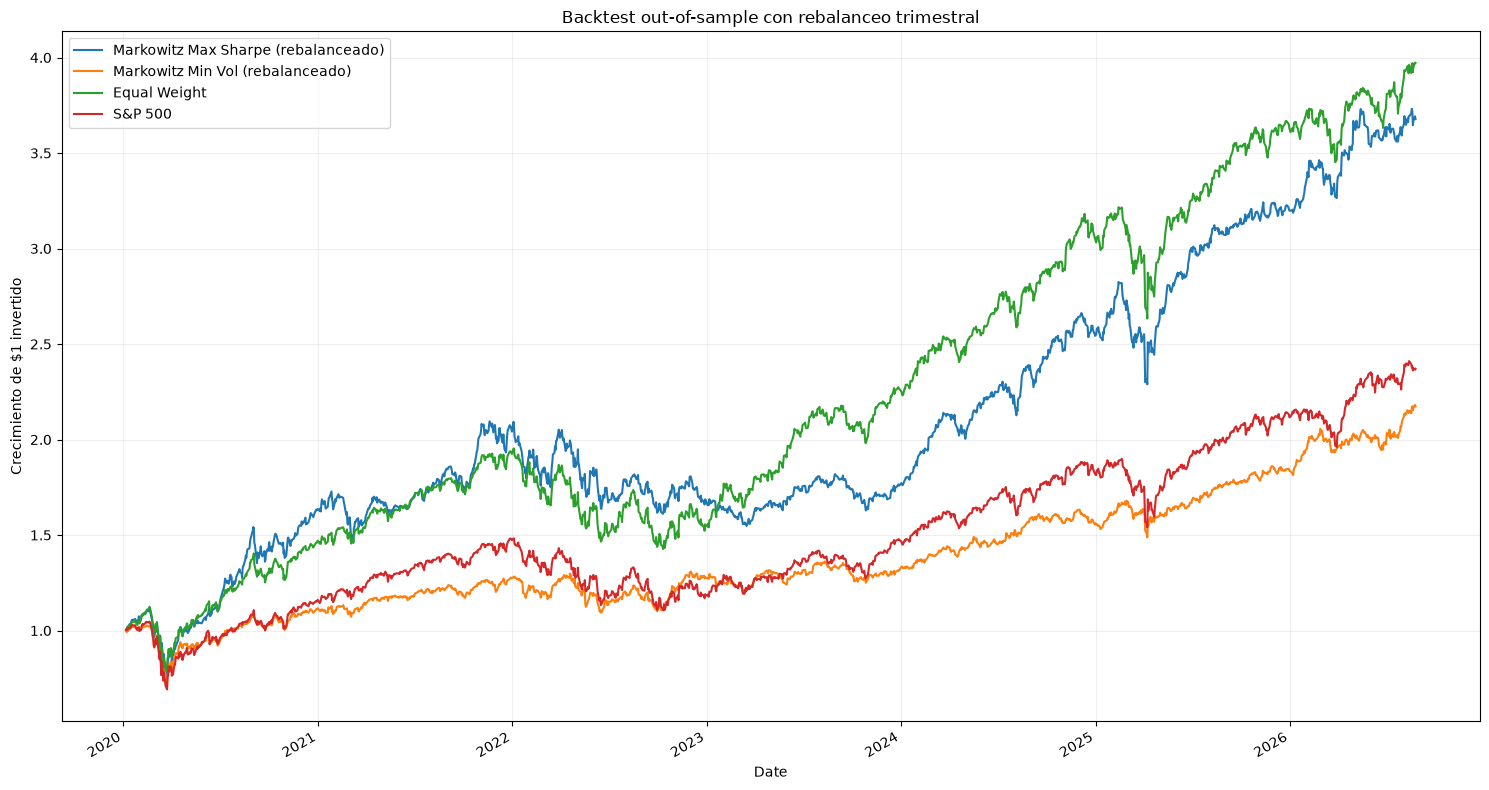

In [6]:
oos_start = returns_max_sharpe.index.min()
oos_end = returns_max_sharpe.index.max()

n_assets = len(asset_returns.columns)
weights_equal = pd.Series(1 / n_assets, index=asset_returns.columns)

returns_equal = (asset_returns.loc[oos_start:oos_end] * weights_equal).sum(axis=1)
returns_benchmark = returns_clean.loc[oos_start:oos_end, benchmark]

comparison_oos = pd.DataFrame({
    "Markowitz Max Sharpe (rebalanceado)": (1 + returns_max_sharpe).cumprod(),
    "Markowitz Min Vol (rebalanceado)": (1 + returns_min_vol).cumprod(),
    "Equal Weight": (1 + returns_equal).cumprod(),
    "S&P 500": (1 + returns_benchmark).cumprod()
}).dropna()

comparison_oos.plot(figsize=(15, 8), title="Backtest out-of-sample con rebalanceo trimestral")
plt.ylabel("Crecimiento de $1 invertido")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_backtest_rebalanceo.png", dpi=300, bbox_inches="tight")
plt.show()


## Tabla de métricas out-of-sample

**Esta es la tabla que realmente responde tu pregunta de investigación**, porque ninguna de estas estrategias usó información del futuro para tomar sus decisiones.

In [7]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    calmar = ann_return / abs(max_drawdown)
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown,
        "Calmar Ratio": calmar
    }

summary_oos = pd.DataFrame({
    col: annualized_metrics(comparison_oos[col]) for col in comparison_oos.columns
}).T.sort_values("Sharpe Ratio", ascending=False)

summary_oos.round(4)


,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown,Calmar Ratio
Equal Weight,0.2293,0.2087,1.0032,-0.2998,0.7650
Markowitz Max Sharpe (rebalanceado),0.2204,0.2176,0.9213,-0.3170,0.6954
Markowitz Min Vol (rebalanceado),0.1311,0.1659,0.6695,-0.3013,0.4350
S&P 500,0.1507,0.2034,0.6429,-0.3392,0.4443


## Análisis de rotación (turnover) y costos de transacción

Cuánto hay que mover el portafolio en cada rebalanceo. Una rotación alta implica más costos y menor viabilidad práctica — es un punto importante para la sección de robustez del informe.

Rotación promedio por rebalanceo (Max Sharpe): 0.4686
Rotación promedio por rebalanceo (Min Vol):    0.1777
Costo total acumulado (Max Sharpe): 0.0127
Costo total acumulado (Min Vol):    0.0048


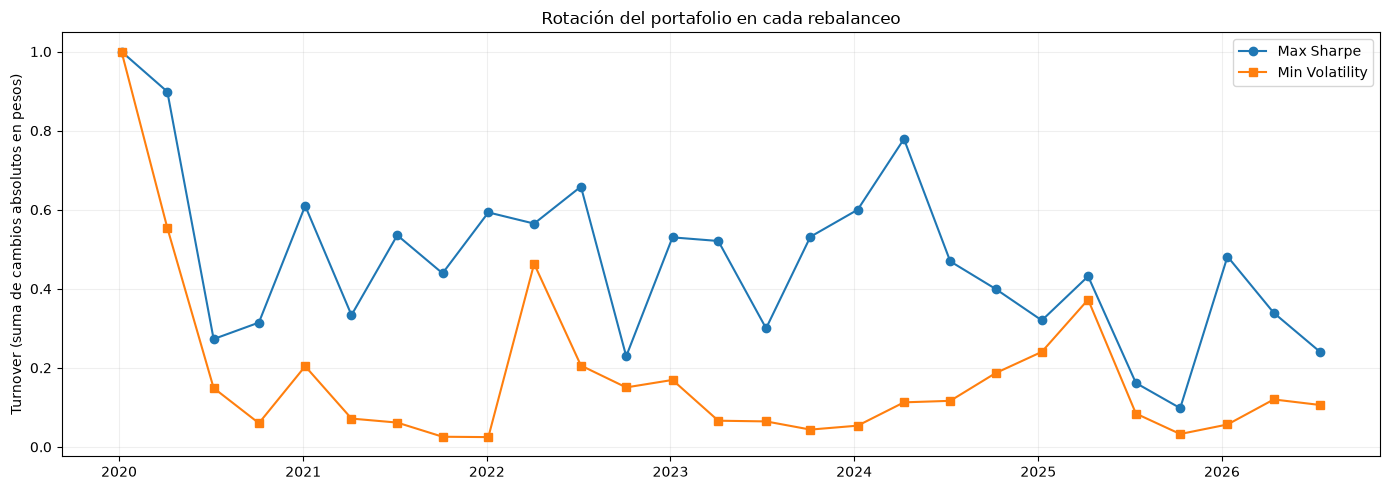

In [8]:
print("Rotación promedio por rebalanceo (Max Sharpe):", turnover_max_sharpe['turnover'].mean().round(4))
print("Rotación promedio por rebalanceo (Min Vol):   ", turnover_min_vol['turnover'].mean().round(4))
print("Costo total acumulado (Max Sharpe):", turnover_max_sharpe['cost'].sum().round(4))
print("Costo total acumulado (Min Vol):   ", turnover_min_vol['cost'].sum().round(4))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(turnover_max_sharpe.index, turnover_max_sharpe["turnover"], marker="o", label="Max Sharpe")
ax.plot(turnover_min_vol.index, turnover_min_vol["turnover"], marker="s", label="Min Volatility")
ax.set_title("Rotación del portafolio en cada rebalanceo")
ax.set_ylabel("Turnover (suma de cambios absolutos en pesos)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_turnover.png", dpi=300, bbox_inches="tight")
plt.show()


## Evolución de los pesos en el tiempo

Muestra qué tan estables (o inestables) son las decisiones del optimizador entre rebalanceos — una señal visual del problema de error de estimación de Markowitz.

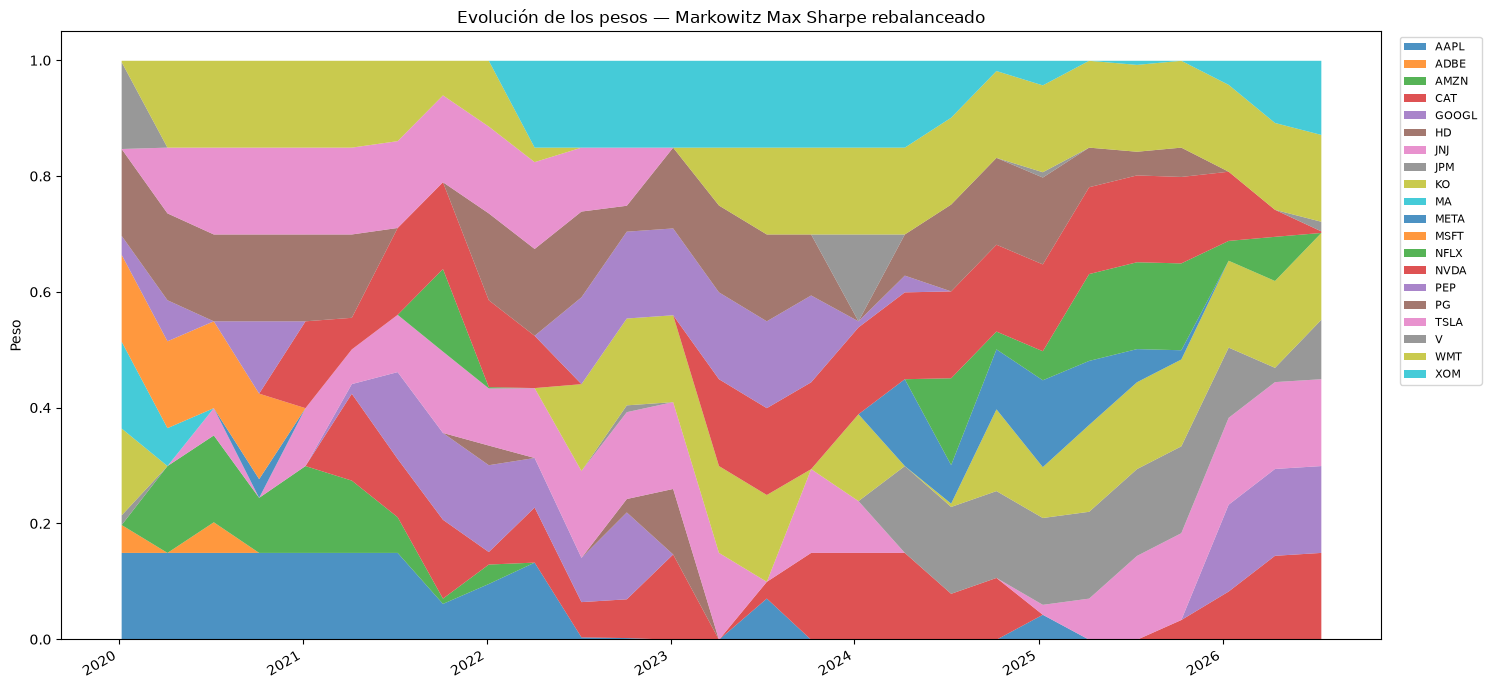

In [9]:
fig, ax = plt.subplots(figsize=(15, 7))
weights_max_sharpe_hist.plot(kind="area", stacked=True, ax=ax, alpha=0.8, linewidth=0)
ax.set_title("Evolución de los pesos — Markowitz Max Sharpe rebalanceado")
ax.set_ylabel("Peso")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_evolucion_pesos.png", dpi=300, bbox_inches="tight")
plt.show()


## Comparación clave: in-sample (Fase 5) vs. out-of-sample (Fase 9)

Esta comparación es el corazón del hallazgo metodológico del proyecto. Completa manualmente la columna in-sample con los valores de la Fase 5 (Max Sharpe: 26.7% / 20.0% / Sharpe 1.24) para tu informe.

In [10]:
in_sample_reference = pd.DataFrame({
    "Retorno anualizado": [0.2673, 0.2224, 0.1392],
    "Volatilidad anualizada": [0.2001, 0.2025, 0.1922],
    "Sharpe Ratio": [1.2360, 0.9997, 0.6201]
}, index=["Markowitz Max Sharpe", "Equal Weight", "S&P 500"])

print("=== IN-SAMPLE (Fase 5, sin rebalanceo) ===")
print(in_sample_reference.round(4).to_string())
print()
print("=== OUT-OF-SAMPLE (Fase 9, con rebalanceo) ===")
print(summary_oos[["Retorno anualizado", "Volatilidad anualizada", "Sharpe Ratio"]].round(4).to_string())


=== IN-SAMPLE (Fase 5, sin rebalanceo) ===
                      Retorno anualizado  Volatilidad anualizada  Sharpe Ratio
Markowitz Max Sharpe              0.2673                  0.2001        1.2360
Equal Weight                      0.2224                  0.2025        0.9997
S&P 500                           0.1392                  0.1922        0.6201

=== OUT-OF-SAMPLE (Fase 9, con rebalanceo) ===
                                     Retorno anualizado  Volatilidad anualizada  Sharpe Ratio
Equal Weight                                     0.2293                  0.2087        1.0032
Markowitz Max Sharpe (rebalanceado)              0.2204                  0.2176        0.9213
Markowitz Min Vol (rebalanceado)                 0.1311                  0.1659        0.6695
S&P 500                                          0.1507                  0.2034        0.6429


## Guardar resultados

In [11]:
comparison_oos.to_csv(RESULTS_DIR / "backtest_oos.csv")
summary_oos.to_csv(RESULTS_DIR / "summary_oos.csv")
weights_max_sharpe_hist.to_csv(RESULTS_DIR / "weights_history_max_sharpe.csv")
turnover_max_sharpe.to_csv(RESULTS_DIR / "turnover_max_sharpe.csv")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\backtesting_rebalanceo
